In [1]:
import numpy as np
import matplotlib.pylab as plt
import pickle

In [2]:
#Decreasing force
filename = 'Block10_CGT.pkl'

with open(filename,'rb') as file:
    CGT01 = pickle.load(file)

In [3]:
#Method
#Bond length
b = 1

#Ree parameters
Nlpf = 10009
M = 100; N = 100
Ndata = int(M*N)
Ncols = 9

#Get segmental end-to-end distance
def segRee(D, Atom_Type):
    Nf = D.shape[0]
    Mseg = N//10*M
    # Reshape by Nf x Mseg x Blck x 9       
    D = D[1:].reshape(Nf-1,Mseg,10,9) #exclude first frame

    Xseg = D[:,:,:,3:6]

    if(Atom_Type == 'Hydrophilic'):
        # Get just the odd segments (hydrophilic segments)
        Xhp =  Xseg[:,1::2,:,:]
    elif(Atom_Type == 'Hydrophobic'):
        # Get just the even segments (hydrophobic segments)
        Xhp =  Xseg[:,0::2,:,:]
    
    # End-to-End vectors of the segments
    dX = Xhp[:,:,-1,:]-Xhp[:,:,0,:]
    Rhp = np.linalg.norm(dX,axis=2)
    return Rhp

In [4]:
#Define bin size and domain of order parameter
bin = 100
domain = [1, 9.11]
rang = np.linspace(domain[0], domain[1], bin + 1)
xh = (rang[:-1]+rang[1:])/2

/tmp/ipykernel_857508/547258413.py:70: RuntimeWarning: divide by zero encountered in log
  F = -0.1*np.log(prob)-k[i]*(xh-R[i])**2


Text(0, 0.5, 'F ($\\epsilon$)')

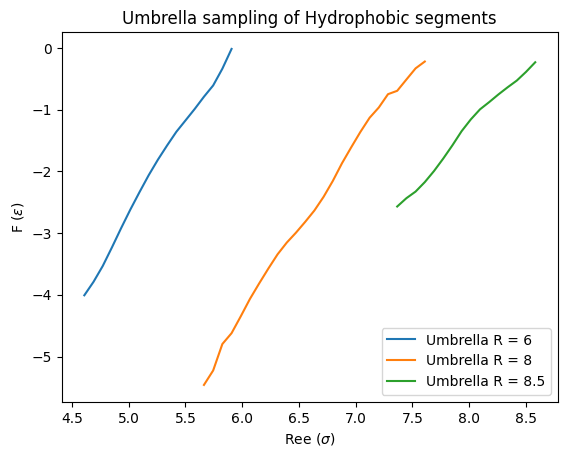

In [5]:
#Umbrella Sampling
paths = [
    '../block10/T0.1/Success :)/R=6/dump.rc2.5N100Tp1',
    '../block10/T0.1/Success :)/R=8/dump.rc2.5N100Tp1',
    '../block10/T0.1/Success :)/R=8.5/dump.rc2.5N100Tp1',
    ]

R = [6, 8, 8.5]
k = [2, 1, 2]
i = 0

R_samples = []

F_umbrella = np.empty((0,bin))

for path in paths:
    
    with open(path, 'r') as file:
        
        LINES = file.readlines()
        
        Nf = len(LINES) // (1009)

        file.seek(0) # go back to start of file

        all_frames=[]

        while True:
            # Skip the non-numeric header lines (assumed to be 9 lines)
            for _ in range(9):
                line = file.readline()
                if not line:
                    break  # End of file
            else:
                # Read the next block of data
                frame_data = np.loadtxt(file, max_rows=1000)
                all_frames.append(frame_data)
                continue
            break  # Exit the loop if EOF

    # Combine all frames into a single numpy array
    D = np.vstack(all_frames).reshape(Nf,1000,9)

    #Sort each frame by atom type
    for f in range(Nf):
        ids = D[f,:,0]
        key = np.argsort(ids)
        D[f,:,:] = D[f,key,:]

    Nf = D.shape[0]

    #Extract all atoms that are type 3
    Type2 = D[D[:,:,2] == 2]
    Type2 = Type2.reshape(Nf, 100, 9)

    #Extract all atoms that are type 4
    Type3 = D[D[:,:,2] == 3]
    Type3 = Type3.reshape(Nf, 100, 9)

    #Extract Position vector
    Type2 = Type2[:,:,3:6]
    Type3 = Type3[:,:,3:6]

    dX = Type2-Type3
    dX.shape
    Ree = np.linalg.norm(dX, axis = 2)
    Ree = Ree[5:,:] #Assume equilibrium after this
    R_samples.append(Ree)
    prob = np.histogram(Ree,bins=rang)[0]
    F = -0.1*np.log(prob)-k[i]*(xh-R[i])**2
    plt.plot(xh, F, label = f'Umbrella R = {R[i]}')
    i+=1
    F_umbrella = np.append(F_umbrella, [F], axis = 0)
    
plt.legend()
plt.title('Umbrella sampling of Hydrophobic segments')
plt.xlabel("Ree ($\sigma$)")
plt.ylabel("F ($\epsilon$)")

/tmp/ipykernel_857508/1019369474.py:8: RuntimeWarning: divide by zero encountered in log
  F = -0.1*np.log(prob)+f*xh
/tmp/ipykernel_857508/1019369474.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0.5, 1.0, 'Free Energy, Block 10, T = 0.1')

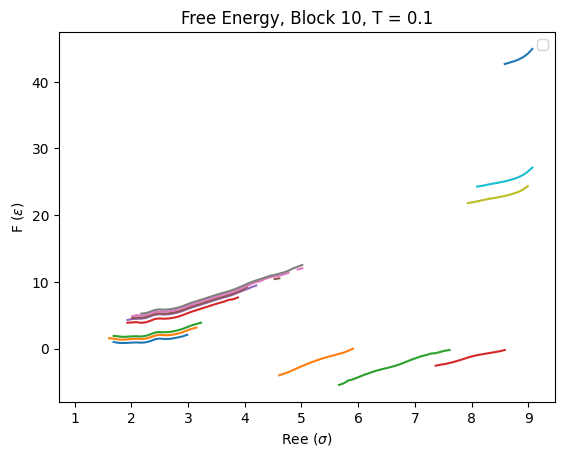

In [28]:
#Find simulations with phase coexistence
Hphobic = np.empty((0,bin))

for i in range(3, 14):
    f = CGT01.f[i]
    D = segRee(CGT01.ParsedRee[i], 'Hydrophobic').flatten()
    prob = np.histogram(D,bins=rang)[0]
    F = -0.1*np.log(prob)+f*xh
    plt.plot(xh, F)
    Hphobic = np.append(Hphobic, [F], axis = 0)

for F in F_umbrella:
    plt.plot(xh, F)
    Hphobic = np.append(Hphobic, [F], axis = 0)

plt.legend()
plt.xlabel("Ree ($\sigma$)")
plt.ylabel("F ($\epsilon$)")
plt.title('Free Energy, Block 10, T = 0.1')

In [7]:
samples = []
for i in range(3, 14):
    D = segRee(CGT01.ParsedRee[i], 'Hydrophobic').flatten()
    samples.append(D)

samples.append(R_samples[0].flatten())
samples.append(R_samples[1].flatten())
samples.append(R_samples[2].flatten())

In [8]:
#Initialize variables for MBAR object

N_k = np.empty((0)) #Number of samples per umbrella simulation
x_n = np.array([]) #Concatenate all observations

for s in samples:
    x_n = np.append(x_n, s)
    N_k = np.append(N_k, s.shape[0])

f = CGT01.f[3:]

#Build reduced potential matrix
u_kn = np.empty((0, x_n.shape[0]))

prob = np.histogram(x_n,bins=rang)[0]
bin_index = np.searchsorted(rang, x_n, side='left') - 1

for i in range(11):
    F = -0.1*np.log(prob)+f[i]*xh
    u = F[bin_index]
    u_kn = np.append(u_kn, [u], axis = 0)

for i in range(3):
    F = -0.1*np.log(prob)-k[i]*(xh-R[i])**2
    u = F[bin_index]
    u_kn = np.append(u_kn, [u], axis = 0)

/tmp/ipykernel_857508/435825884.py:19: RuntimeWarning: divide by zero encountered in log
  F = -0.1*np.log(prob)+f[i]*xh
/tmp/ipykernel_857508/435825884.py:24: RuntimeWarning: divide by zero encountered in log
  F = -0.1*np.log(prob)-k[i]*(xh-R[i])**2


In [9]:
#Build MBAR object
from pymbar import MBAR

mbar = MBAR(u_kn, N_k)
results = mbar.compute_free_energy_differences()

Warning on use of the timeseries module: If the inherent timescales of the system are long compared to those being analyzed, this statistical inefficiency may be an underestimate.  The estimate presumes the use of many statistically independent samples.  Tests should be performed to assess whether this condition is satisfied.   Be cautious in the interpretation of the data.

****** PyMBAR will use 64-bit JAX! *******
* JAX is currently set to 32-bit bitsize *
* which is its default.                  *
*                                        *
* PyMBAR requires 64-bit mode and WILL   *
* enable JAX's 64-bit mode when called.  *
*                                        *
* This MAY cause problems with other     *
* Uses of JAX in the same code.          *
******************************************


******* JAX 64-bit mode is now on! *******
*     JAX is now set to 64-bit mode!     *
*   This MAY cause problems with other   *
*      uses of JAX in the same code.     *
******************

In [22]:
dist = results['Delta_f']

In [15]:
offset = []
for i in range(14):
    offset.append(dist[0, i])

offset

[np.float64(0.0),
 np.float64(1.967718849401125),
 np.float64(3.7085187343317916),
 np.float64(6.986956955431788),
 np.float64(7.756277003489046),
 np.float64(7.905102378278912),
 np.float64(8.199552919669115),
 np.float64(8.490651221261366),
 np.float64(9.208298977967262),
 np.float64(9.91624422358425),
 np.float64(15.390645675140568),
 np.float64(-23.37164809150284),
 np.float64(-27.77575229890791),
 np.float64(-73.96892986706237)]

/tmp/ipykernel_857508/3306525747.py:4: RuntimeWarning: divide by zero encountered in log
  F = -0.1*np.log(prob)+f[i]*xh-offset[i]
/tmp/ipykernel_857508/3306525747.py:11: RuntimeWarning: divide by zero encountered in log
  F = -0.1*np.log(prob)-k[i]*(xh-R[i])**2-offset[c]


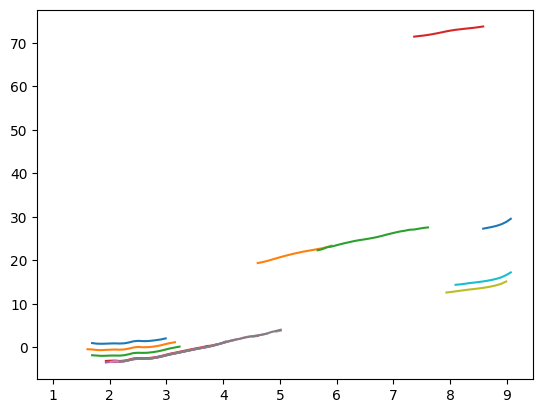

In [17]:
for i in range(11):
    D = samples[i]
    prob = np.histogram(D,bins=rang)[0]
    F = -0.1*np.log(prob)+f[i]*xh-offset[i]
    plt.plot(xh, F)

c = 11
for i in range(3):
    D = samples[c]
    prob = np.histogram(D,bins=rang)[0]
    F = -0.1*np.log(prob)-k[i]*(xh-R[i])**2-offset[c]
    plt.plot(xh, F)
    c+=1